# Imports

In [14]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)


In [109]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    precision_recall_curve, precision_score, recall_score, f1_score,
    confusion_matrix, balanced_accuracy_score, roc_auc_score, average_precision_score
)

In [130]:
data = pd.read_csv('monthly_master.csv')

In [131]:
data.head()

,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,...,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad,total_min_open,total_min_paused,total_min_closed,total_minutes_all
0,100000,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
1,100000,2024-11,10.0,99900.0,4,0.192647,1122.625000,0.250000,0.000000,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
2,100000,2024-12,100.0,1494618.0,23,0.213178,1175.461111,0.444444,0.000000,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
3,100000,2025-01,78.0,1165196.0,20,0.395979,1168.689600,0.240000,0.120000,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
4,100000,2025-02,48.0,808800.0,15,0.400081,1171.896667,0.166667,0.111111,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN


### Diccionario de variables (monthly_master)

| Variable | Tipo | Descripción |
|---|---|---|
| `store_id` | int/str | Identificador único de la tienda. |
| `period_month` | str (YYYY-MM) | Mes de referencia del registro. |
| `tpn` | int | Pedidos/ventas netas del mes (Total Pedidos Netos). |
| `gmv` | float | Gross Merchandise Value del mes (monto total vendido). |
| `days_with_orders` | int | Días del mes con al menos un pedido. |
| `markdown_mean` | float | Descuento/promoción promedio aplicado en el mes (0–1). |
| `avg_shipping_cost` | float | Costo de envío promedio por pedido en el mes. |
| `si_ios_prop` | float | Proporción de pedidos por canal iOS (0–1). |
| `si_meli_prop` | float | Proporción de pedidos por canal MELI/web (0–1). |
| `si_other_prop` | float | Proporción de pedidos por otros canales (0–1). |
| `free_shipping_prop` | float | Proporción de pedidos con envío gratis (0–1). |
| `churn` | {0,1} | Flag de churn en el mes (1 = churn). |
| `churn_streak` | int | Cantidad de meses consecutivos en churn hasta el mes actual. |
| `churn_2m_consec` | {0,1} | 1 si acumula ≥2 meses consecutivos en churn. |
| `churn_4m_consec_or_more` | {0,1} | 1 si acumula ≥4 meses consecutivos en churn. |
| `churn_unique` | {0,1} | 1 si el churn de este mes es el **primer** churn del streak. |
| `stage` | str | Etapa de la tienda (p.ej., `Activo`, `Inactivo`, `New`). |
| `created_date` | date | Fecha de creación de la tienda. |
| `segmento` | str | Segmento comercial asignado a la tienda. |
| `comision_actual` | float | % de comisión vigente (0–1 o 0–100 según fuente). |
| `in-house_delivery` | {0,1} | 1 si la tienda utiliza logística propia. |
| `store_type` | str | Tipo de tienda (cadena, independiente, etc.). |
| `barrio` | str | Barrio de la tienda. |
| `category` | str | Categoría principal (cocina/rubro). |
| `cooking_time` | float/int | Tiempo de preparación estimado (minutos). |
| `tiene_otra_app` | {0,1} | 1 si opera en otras apps/plataformas. |
| `brand_id` | str/int | Identificador de la marca/cadena (si corresponde). |
| `total_min_open` | float/int | Minutos con estado **OPEN** en el mes. |
| `total_min_paused` | float/int | Minutos con estado **PAUSED** en el mes. |
| `total_min_closed` | float/int | Minutos con estado **CLOSED** en el mes. |
| `total_minutes_all` | float/int | Suma de minutos Open+Paused+Closed en el mes. |

In [133]:
# Eliminar columnas que no vamos a usar
cols_to_drop = ['si_ios_prop', 'si_meli_prop', 'si_other_prop', 'store_type']
data = data.drop(columns=cols_to_drop, errors='ignore')

# Calcular conectividad por fila
num = pd.to_numeric(data['total_min_open'], errors='coerce')
den = pd.to_numeric(data['total_minutes_all'], errors='coerce')

data['connectivity'] = np.where(den > 0, num / den, np.nan)
data['connectivity'] = data['connectivity'].clip(0, 1)

# Data engineering

Filtrado de la base para trabajar solo con data de CABA y periodo de análisis 2025.

In [150]:
df0 = data.copy()
df0['period_month'] = pd.to_datetime(df0['period_month'])
df0 = df0.query("ciudad == 'CABA' and period_month.dt.year == 2025 and period_month.dt.month < 9").copy()

### Definición de población elegible y preparación del set de modelado

**Objetivo.** Predecir, a comienzos de cada mes _t_, la probabilidad de que una tienda entre en *churn* (primer mes de churn: `churn_unique = 1`) durante ese mismo mes _t_, usando solo información disponible hasta _t-1_.

**Problema detectado.** En la base existen filas “pre-alta” (meses anteriores a la creación de la tienda) donde `churn_unique` es `NaN`. Es correcto que existan para la grilla mensual, pero **no deben participar** ni en el entrenamiento ni en la evaluación, porque la tienda **aún no era elegible** en esos meses.

**Qué hacemos.**
1. **Normalizamos fechas** y definimos `created_month` como el primer día del mes de alta de la tienda.
2. **Población elegible por mes:** filtramos solo las filas donde `period_month ≥ created_month`.  
   > Denominador correcto = *tiendas ya creadas en ese mes*.
3. **Target definido:** excluimos filas con `churn_unique` `NaN` y tipamos `churn_unique` a binario (0/1).
4. **Edad:** calculamos `age_months = period_month − created_month` para:
   - exigir historia mínima (p. ej., ≥1 o ≥3 meses) si usamos *lags/rollings*, o
   - usarla como feature de control.

**Beneficio.**
- Evitamos fuga de información y sesgos de denominador.
- Las tasas de churn y las métricas del modelo reflejan la realidad operativa: solo tiendas **existentes** en cada mes.


In [ ]:
# === CONTEXTO ELEGIBLE (SIN descartar NaN del target) ===
df_base = df0.copy()
df_base['period_month'] = pd.to_datetime(df_base['period_month'])
df_base['created_date'] = pd.to_datetime(df_base['created_date'], errors='coerce')
df_base['created_month'] = df_base['created_date'].dt.to_period('M').dt.to_timestamp()

# Fallback si falta created_date -> primer mes observado del store
first_obs = df_base.groupby('store_id')['period_month'].transform('min')
df_base['created_month'] = df_base['created_month'].fillna(first_obs)

# Solo filas "ya creadas" (población elegible)
mask_alive = (df_base['period_month'] >= df_base['created_month'])
df_ctx_all = df_base.loc[mask_alive].copy()   # <-- NO descartamos NaN en churn_unique

# (Opcional) edad en meses (robusta)
pm_y, pm_m = df_ctx_all['period_month'].dt.year, df_ctx_all['period_month'].dt.month
cm_y, cm_m = df_ctx_all['created_month'].dt.year, df_ctx_all['created_month'].dt.month
df_ctx_all['age_months'] = ((pm_y - cm_y) * 12 + (pm_m - cm_m)).clip(lower=0).astype(int)

# Vista SOLO para entrenar/validar (target definido)
df_ctx_train = df_ctx_all[df_ctx_all['churn_unique'].notna()].copy()
df_ctx_train['churn_unique'] = df_ctx_train['churn_unique'].astype(int)

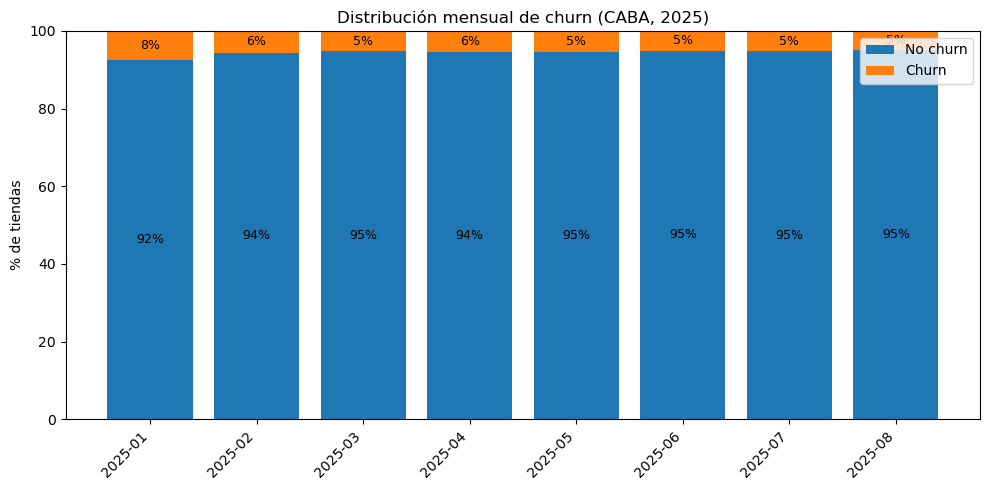

In [179]:
# Visualizamos el desbalance de la variable objetivo 'churn' por mes

df_plot = df_ctx_all.copy()
df_plot = df_plot[df_plot['period_month'] <= pd.Timestamp('2025-08-31')]
df_plot = df_plot[df_plot['churn_unique'].notna()].copy()

pct = (
    df_plot.groupby('period_month')['churn_unique']
    .value_counts(normalize=True)
    .rename('pct')
    .mul(100)
    .reset_index()
    .pivot(index='period_month', columns='churn_unique', values='pct')
    .fillna(0.0)
    .rename(columns={0: 'No churn', 1: 'Churn'})
    .sort_index()
)

# Asegurar que las columnas estén en orden
pct = pct[['No churn', 'Churn']]

# Plot barras apiladas
labels = pct.index.strftime('%Y-%m')
no_churn = pct['No churn'].values
churn = pct['Churn'].values

x = np.arange(len(labels))
width = 0.8

plt.figure(figsize=(10, 5))
# barra de No churn
plt.bar(x, no_churn, width)
# barra de Churn (apilada arriba)
plt.bar(x, churn, width, bottom=no_churn)

# Etiquetas de % arriba de cada segmento
for i in range(len(x)):
    # etiqueta "No churn"
    if no_churn[i] > 0:
        plt.text(x[i], no_churn[i]/2, f"{no_churn[i]:.0f}%", ha='center', va='center', fontsize=9)
    # etiqueta "Churn"
    if churn[i] > 0:
        plt.text(x[i], no_churn[i] + churn[i]/2, f"{churn[i]:.0f}%", ha='center', va='center', fontsize=9)

plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel('% de tiendas')
plt.title('Distribución mensual de churn (CABA, 2025)')
plt.ylim(0, 100)
plt.legend(['No churn', 'Churn'], loc='upper right')
plt.tight_layout()
plt.show()

Creación de variables de lags (hasta t-1) para evitar data leakage. Se hace para las siguientes variables:
- tpn
- gmv
- days_with_orders
- markdown_mean
- avg_shipping_cost
- free_shipping_prop
- connectivity
- total_min_open
- total_minutes_all
- churn_streak

In [180]:
num_cols = [
    'tpn','gmv','days_with_orders','markdown_mean','avg_shipping_cost',
    'free_shipping_prop','connectivity','total_min_open','total_minutes_all','churn_streak'
]

def add_lag_feats(g, cols, lags=(1,2,3)):
    for c in cols:
        for L in lags:
            g[f'{c}_lag{L}'] = g[c].shift(L)
    return g

def add_roll_feats(g, cols, win=3):
    for c in cols:
        g[f'{c}_roll{win}_mean'] = g[c].shift(1).rolling(win).mean()   # hasta t-1
        g[f'{c}_roll{win}_std']  = g[c].shift(1).rolling(win).std()
    return g

def add_deltas(g):
    # ejemplos sobre tpn
    g['tpn_delta_1m'] = g['tpn_lag1'] - g['tpn_lag2']
    g['tpn_pctchg_1m'] = np.where((g['tpn_lag2']>0),
                                  (g['tpn_lag1']/g['tpn_lag2'] - 1.0),
                                  np.nan)
    # ratio open en t-1
    g['open_rate_lag1'] = np.where(g['total_minutes_all_lag1']>0,
                                   g['total_min_open_lag1']/g['total_minutes_all_lag1'],
                                   np.nan)
    # historial churn
    g['churn_prev'] = g['churn_unique'].shift(1)
    g['en_churn_streak_prev'] = (g['churn_streak'].shift(1) > 0).astype('float')
    return g

df = (df_ctx_all.sort_values(['store_id','period_month'])
        .groupby('store_id', group_keys=False)
        .apply(lambda g: add_lag_feats(g, num_cols))
        .groupby('store_id', group_keys=False)
        .apply(lambda g: add_roll_feats(g, num_cols, win=3))
        .groupby('store_id', group_keys=False)
        .apply(add_deltas))

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_30607/261782932.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_lag_feats(g, num_cols))
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_30607/261782932.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_roll_feats(g, num_cols, win=3))
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_30607/2

Encoding de las variables categóricas.

In [181]:
cat_cols = ['segmento', 'barrio', 'category']
for c in cat_cols:
    if c in df_ctx_all.columns:
        df_ctx_all[c] = df_ctx_all[c].astype('category')

Selección final de variables

In [182]:
# Selección final de columnas y limpieza ===
target_col = 'churn_unique'
drop_now = num_cols  # los valores “t” crudos no se usan (evitá leakage)
df = df.drop(columns=drop_now, errors='ignore')  # evita columnas "t" crudas
base_cols = ['store_id','period_month', target_col] + cat_cols
lag_feats = [c for c in df.columns if any(s in c for s in ['_lag','_roll','_std','delta','pctchg','open_rate_lag1','churn_prev','en_churn_streak_prev'])]

Xy = df[base_cols + lag_feats].copy()

# Imputaciones simples + flags
for c in lag_feats:
    if c not in Xy.columns:
        continue
    if str(Xy[c].dtype).startswith('float') or str(Xy[c].dtype).startswith('int'):
        Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
        Xy[c] = Xy[c].fillna(0.0)

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_30607/1659618683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_30607/1659618683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_30607/1659618683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra

# # Resumen Modelo 1 - LightGBM baseline

### Objetivo
Predecir **al inicio de cada mes _t_** la probabilidad de que una tienda entre en **primer mes de churn** durante _t_ (`churn_unique = 1`), usando **solo información disponible hasta _t−1_**.

---

### Población y split temporal
- **Ámbito:** CABA, año **2025**.  
- **Población elegible por mes:** solo tiendas con `period_month ≥ created_month` (evita filas “pre-alta”).  
- **Splits:**  
  - **Train:** 2025-04 a 2025-06  
  - **Validación:** **2025-07**  
  - **Test (hold-out):** **2025-08**  
- **Prevalencia (base rate):** valid **5.26%**, test **4.85%**.

---

### Variable objetivo
- `churn_unique` (binaria 0/1): **1** si el mes es el **primer** mes del streak de churn (si vendió el mes anterior y el actual no vendió); **0** en caso contrario.  
- Se excluyeron filas con `churn_unique` no definido (NaN).

---

### Variables y transformaciones (as-of _t−1_)
- **Numéricas base:** `tpn`, `gmv`, `days_with_orders`, `markdown_mean`, `avg_shipping_cost`, `free_shipping_prop`, `connectivity` (def.: `total_min_open/total_minutes_all`), `total_min_open`, `total_minutes_all`, `churn_streak`.  
- **Derivadas (todas “cerradas a la izquierda”):**
  - **Lags:** `_lag1`, `_lag2`, `_lag3`
  - **Rolling 3m (sobre _t−1_):** `_roll3_mean`, `_roll3_std`
  - **Tendencias:** `tpn_delta_1m = tpn_lag1 − tpn_lag2`, `tpn_pctchg_1m`
  - **Operativas:** `open_rate_lag1 = total_min_open_lag1 / total_minutes_all_lag1`
  - **Historial churn:** `churn_prev = churn_unique_lag1`, `en_churn_streak_prev = (churn_streak_lag1 > 0)`
- **Categóricas:** `segmento`, `barrio`, `category` (dtype `category`).  
- **Variables descartadas:** `stage` del mes _t_ (leakage), `si_ios_prop`, `si_meli_prop`, `si_other_prop`, `store_type`.  
- **Imputación:** `fillna(0.0)` en lags/rollings numéricos + **flags de imputación** `*_nanflag`.

---

### Modelo y entrenamiento
- **Algoritmo:** LightGBM (GBDT, `objective='binary'`).  
- **Parámetros base:** `learning_rate=0.05`, `num_leaves≈31`, `feature_fraction=0.9`, `bagging_fraction=0.9`, `min_child_samples=50`, `reg_lambda=5.0`.  
- **Desbalance:** `scale_pos_weight = (negativos/positivos)` calculado en train.  
- **Callbacks:** early stopping y logging.  
- **Selección de umbral:** por **F2** en validación (privilegia recall). Umbral elegido **0.5421** y aplicado tal cual en test.

---

### Métricas principales (sobre toda la base, sin Top-K)

| Split | Threshold | Precision | Recall | F2 | AUC | AUPRC | Base rate |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Valid (Jul-2025)** | 0.5421 | **0.326** | **0.760** | **0.600** | **0.925** | **0.401** | 0.0526 |
| **Test  (Ago-2025)** | 0.5421 | **0.311** | **0.725** | — | **0.931** | **0.371** | 0.0485 |

**Matriz de confusión (Valid):** TN=3012, FP=287, FN=44, TP=139  
**Matriz de confusión (Test):**  TN=3277, FP=292, FN=50,  TP=132

> **Lectura:** Con base rate ~5%, el **AUPRC 0.37–0.40** implica un **lift x7–8** vs. azar. El umbral orientado a recall captura ~**73–76%** de los onsets a costa de **precisión ~0.31–0.33** (falsos positivos operativos).

---

### Chequeos de fuga (data leakage)
- **Población elegible** por mes (no “pre-alta”).  
- **Features as-of _t−1_** (lags/rollings con `shift(1)` sobre `store_id, period_month` ordenados).  
- **Exclusión explícita** de `stage` en _t_ (principal fuente de fuga).  
- **Val/Test** con métricas muy similares ⇒ sin sobreajuste evidente y **sin señales de leakage** remanente.

---

### Análisis por streak en mes _t_ (Valid Jul-2025)
- **TP:** 100% con `churn_streak>0` (coherente con onset).  
- **FN:** 100% con `churn_streak>0` (onsets que el modelo no capturó).  
- **FP:** 100% con `churn_streak=0` (alarmas de onset que **no** se materializaron).  
- **TN:** 31.7% con `streak>0` (continuaciones de churn correctamente no marcadas como onset) y 68.3% sin streak.

**Mayor punto de dolor:** **falsos positivos de onset** (tiendas sin streak en _t_ que el modelo marca como riesgo). Esto afecta la **precisión** (~0.31–0.33) más que el recall.

---

### Próximos pasos recomendados
1. **Umbral por ROI** (en vez de F2): elegir el threshold que maximiza **valor esperado** dado costo por contacto y beneficio por churn evitado.  
2. **Tuning de desbalance:** barrer `scale_pos_weight` alrededor del ratio empírico (±20%).  
3. **Más señal “pre-churn” para bajar FP manteniendo recall:**  
   - Tendencias de actividad (`days_with_orders`/`tpn`: rollings, deltas, %chg),  
   - Conectividad (`connectivity_lag1`, `connectivity_roll3_mean`) e **interacciones** con actividad.  
4. **Regla post-modelo suave** (opcional): mantener `yhat=1` solo si (conectividad baja **o** tendencia negativa **o** caída en `days_with_orders`), monitorizando el trade-off recall/precisión.  
5. **Calibración** (si se comunican probabilidades): Isotonic en valid y aplicación en test.

In [183]:
def _predict_proba_pos(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]
    return model.predict(X, num_iteration=getattr(model, "best_iteration_", getattr(model, "best_iteration", None)))

def _pick_threshold_by_fbeta(y_true, y_score, beta=2.0):
    y = pd.Series(y_true).astype(int).values
    s = np.asarray(y_score)
    p, r, t = precision_recall_curve(y, s)
    t = np.r_[t, 1.0]
    b2 = beta**2
    f = (1+b2) * (p*r) / (b2*p + r + 1e-12)
    i = np.nanargmax(f)
    return float(t[i]), float(p[i]), float(r[i]), float(f[i])

def train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    *,
    target_col="churn_unique",
    id_cols=("store_id","period_month"),
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,     # lista explícita de features a usar; si None -> auto
    params=None,              # dict LightGBM; si None uso defaults
    num_boost_round=2000,
    early_stopping_rounds=200,
    log_period=100,
    auto_scale_pos_weight=True,
    scale_pos_weight=None,
    output_mode="binary",     # "binary" o "proba"
    threshold_strategy="f2",  # si output_mode="binary": "f2" o "fixed"
    fixed_threshold=None,     # usado si threshold_strategy="fixed"
    beta=2.0                  # usado si threshold_strategy="f2"
):
    """
    Entrena LightGBM y devuelve probabilidades y (opcional) predicción binaria.
    """
    # 1) preparar datos
    data = Xy.copy()
    # tipar categóricas
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype("category")

    # features
    if features_to_use is None:
        excl = set(id_cols) | {target_col}
        features = [c for c in data.columns if c not in excl]
    else:
        features = list(features_to_use)

    features = [c for c in features if c not in (set(id_cols) | {target_col})]

    # splits
    X_train, y_train = data.loc[train_mask, features], data.loc[train_mask, target_col]
    X_valid, y_valid = data.loc[valid_mask, features], data.loc[valid_mask, target_col]
    X_test,  y_test  = data.loc[test_mask,  features], data.loc[test_mask,  target_col]

    # Guards de sanidad
    if X_test.shape[0] == 0:
        raise ValueError("X_test está vacío: el test_mask no seleccionó filas. No filtres NaN del target para el mes de predicción y asegurá que generaste features para ese mes.")
    assert y_train.notna().all(), "y_train tiene NaN; ajustá el train_mask para excluirlos."
    assert y_valid.notna().all(), "y_valid tiene NaN; ajustá el valid_mask para excluirlos."

    cat_features = [c for c in cat_cols if c in X_train.columns]

    # desbalance
    if auto_scale_pos_weight and scale_pos_weight is None:
        pos = max(1, int(y_train.sum()))
        neg = len(y_train) - pos
        scale_pos_weight = neg/pos

    # parámetros
    base_params = dict(
        objective="binary",
        metric=["auc","average_precision"],
        boosting_type="gbdt",
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_data_in_leaf=50,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        bagging_freq=1,
        lambda_l1=0.0,
        lambda_l2=5.0,
        verbose=-1
    )
    if scale_pos_weight is not None:
        base_params["scale_pos_weight"] = scale_pos_weight
    if params:
        base_params.update(params)

    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features, free_raw_data=False)
    lgb_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_features, reference=lgb_train, free_raw_data=False)

    callbacks = [lgb.early_stopping(stopping_rounds=early_stopping_rounds),
                 lgb.log_evaluation(period=log_period)]

    model = lgb.train(
        base_params, lgb_train,
        num_boost_round=num_boost_round,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train","valid"],
        callbacks=callbacks
    )

    # 2) probabilidades
    valid_prob = _predict_proba_pos(model, X_valid)
    test_prob  = _predict_proba_pos(model, X_test)

    out = {
        "model": model,
        "features": features,
        "cat_features": cat_features,
        "y_train": y_train, "y_valid": y_valid, "y_test": y_test,
        "valid_prob": valid_prob, "test_prob": test_prob,
        "params_used": base_params
    }

    # 3) predicción binaria (opcional)
    if output_mode == "binary":
        if threshold_strategy == "f2":
            thr, p_f2, r_f2, f2 = _pick_threshold_by_fbeta(y_valid, valid_prob, beta=beta)
        elif threshold_strategy == "fixed":
            if fixed_threshold is None:
                raise ValueError("Debes pasar fixed_threshold cuando threshold_strategy='fixed'")
            thr = float(fixed_threshold)
            p_f2 = r_f2 = f2 = None
        else:
            raise ValueError("threshold_strategy debe ser 'f2' o 'fixed'")

        out.update({
            "threshold": thr,
            "metrics_valid_f2": dict(precision=p_f2, recall=r_f2, F2=f2) if p_f2 is not None else None,
            "valid_pred_bin": (valid_prob >= thr).astype(int),
            "test_pred_bin":  (test_prob  >= thr).astype(int)
        })

    return out


Entranamiento del modelo

In [185]:
# Split temporal
train_mask = Xy['period_month'].between('2025-04-01','2025-06-30') & Xy['churn_unique'].notna()
valid_mask = Xy['period_month'].between('2025-07-01','2025-07-31') & Xy['churn_unique'].notna()
test_mask  = Xy['period_month'].between('2025-08-01','2025-08-31')

# sanity: tamaños y fechas de cada split
print("Train range:", Xy.loc[train_mask, 'period_month'].min(), "→", Xy.loc[train_mask, 'period_month'].max(), 
      "n=", sum(train_mask))
print("Valid range:", Xy.loc[valid_mask, 'period_month'].min(), "→", Xy.loc[valid_mask, 'period_month'].max(), 
      "n=", sum(valid_mask))
print("Test  range:", Xy.loc[test_mask,  'period_month'].min(), "→", Xy.loc[test_mask,  'period_month'].max(), 
      "n=", sum(test_mask))

run_bin = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,        # usa todas las columnas (menos ids y target)
    output_mode="binary",        # ← binario
    threshold_strategy="f2",     # ← elige umbral por F2 (beta=2)
    beta=2.0
)

y_valid    = run_bin["y_valid"]
y_test     = run_bin["y_test"]
valid_pred = run_bin["valid_prob"]   # <- probabilidades en VALID (no binario)
test_pred  = run_bin["test_prob"]    # <- probabilidades en TEST  (no binario)

# Si querés usar el mismo umbral que eligió la función (por F2):
thr_f2 = run_bin["threshold"]

Train range: 2025-04-01 00:00:00 → 2025-06-01 00:00:00 n= 8890
Valid range: 2025-07-01 00:00:00 → 2025-07-01 00:00:00 n= 3482
Test  range: 2025-08-01 00:00:00 → 2025-08-01 00:00:00 n= 5293
Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.992335	train's average_precision: 0.828223	valid's auc: 0.924314	valid's average_precision: 0.411462
[200]	train's auc: 0.999416	train's average_precision: 0.982245	valid's auc: 0.921225	valid's average_precision: 0.401863
Early stopping, best iteration is:
[35]	train's auc: 0.96439	train's average_precision: 0.499825	valid's auc: 0.92598	valid's average_precision: 0.407151


Evaluación de performance del modelo

In [186]:
# ---------- helpers de limpieza/alineación ----------
def _align_dropna(y_true, y_score):
    y = pd.Series(y_true).reset_index(drop=True)
    s = np.asarray(y_score)
    mask = y.notna().values
    return y[mask].astype(int).values, s[mask]

# ---------- selección de umbral por F-beta (favor recall) ----------
def pick_threshold_by_fbeta(y_true, y_score, beta=2.0):
    y, s = _align_dropna(y_true, y_score)
    p, r, t = precision_recall_curve(y, s)
    t = np.r_[t, 1.0]  # igualar largo
    beta2 = beta**2
    fbeta = (1+beta2) * (p*r) / (beta2*p + r + 1e-12)
    i = np.nanargmax(fbeta)
    return float(t[i]), float(p[i]), float(r[i]), float(fbeta[i])

# ---------- evaluación completa a un umbral ----------
def evaluate_at_threshold(y_true, y_score, thr):
    y, s = _align_dropna(y_true, y_score)
    y_hat = (s >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_hat, labels=[0,1]).ravel()
    metrics = {
        "threshold": round(thr, 4),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "precision": precision_score(y, y_hat, zero_division=0),
        "recall": recall_score(y, y_hat, zero_division=0),
        "specificity": tn / (tn + fp) if (tn+fp)>0 else 0.0,
        "f1": f1_score(y, y_hat, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, y_hat),
        "AUC": roc_auc_score(y, s),
        "AUPRC": average_precision_score(y, s),
        "base_rate": y.mean()
    }
    cm = np.array([[tn, fp],[fn, tp]])
    return metrics, cm

# ---------- gráfico de matriz de confusión ----------

def plot_confusion(cm, title="Matriz de confusión", percent=False):
    """
    cm: np.array([[TN, FP],[FN, TP]])
    percent: si True, anota porcentajes de cada celda sobre el total
    """
    vmin, vmax = 0, cm.max() if cm.size else 1
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('RdYlGn')
    

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No churn', 'Churn'])
    ax.set_yticklabels(['No churn', 'Churn'])

    total = cm.sum()
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            txt_color = "white" if norm(val) > 0.5 else "black"
            label = f"{val:,}"
            if percent and total > 0:
                label += f"\n({val/total:.1%})"
            ax.text(j, i, label, ha="center", va="center", fontsize=11, color=txt_color, fontweight='bold' if i==j else 'normal')

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Frecuencia', rotation=90, labelpad=10)
    plt.tight_layout()
    plt.show()

Umbral elegido (F2): 0.5237
VALID → P=0.325 | R=0.770 | F2=0.605

— VALID —


,valor
threshold,0.523700
TP,141.000000
FP,293.000000
TN,3006.000000
FN,42.000000
precision,0.324885
recall,0.770492
specificity,0.911185
f1,0.457050
balanced_accuracy,0.840839



— TEST —


,valor
threshold,0.523700
TP,135.000000
FP,297.000000
TN,3272.000000
FN,47.000000
precision,0.312500
recall,0.741758
specificity,0.916783
f1,0.439739
balanced_accuracy,0.829271


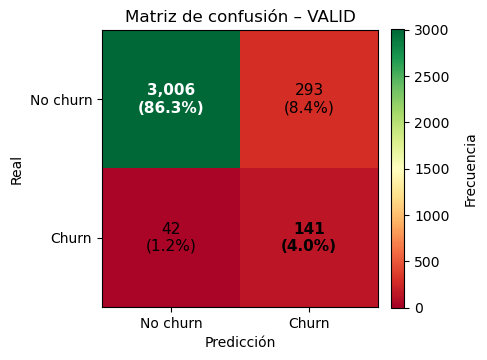

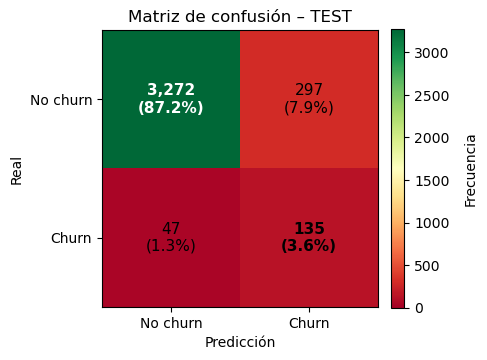

In [187]:
# ===================== uso =====================

# 1) umbral por F2 en VALID
thr_f2, p_f2, r_f2, f2 = pick_threshold_by_fbeta(y_valid, valid_pred, beta=2.0)

print(f"Umbral elegido (F2): {thr_f2:.4f}")
print(f"VALID → P={p_f2:.3f} | R={r_f2:.3f} | F2={f2:.3f}")

# 2) Métricas  (VALID / TEST)
valid_metrics, valid_cm = evaluate_at_threshold(y_valid, valid_pred, thr_f2)
test_metrics,  test_cm  = evaluate_at_threshold(y_test,  test_pred,  thr_f2)

def _nice(df_metrics):
    df = pd.DataFrame([df_metrics]).T
    df.columns = ["valor"]
    for k in ["precision","recall","specificity","f1","balanced_accuracy","AUC","AUPRC","base_rate"]:
        if k in df.index:
            df.loc[k, "valor"] = float(df.loc[k, "valor"])
    return df

print("\n— VALID —")
display(_nice(valid_metrics))

print("\n— TEST —")
display(_nice(test_metrics))

# 3) Matrices de confusión
plot_confusion(valid_cm, title="Matriz de confusión – VALID", percent=True)
plot_confusion(test_cm,  title="Matriz de confusión – TEST",  percent=True)

,feature,gain,split,gain_norm
3,tpn_lag1,44290.852486,63,0.368977
9,days_with_orders_lag1,37677.243821,70,0.313880
6,gmv_lag1,4182.332823,55,0.034842
1,barrio,3439.974401,39,0.028658
53,tpn_delta_1m,3404.856414,40,0.028365
38,days_with_orders_roll3_std,2095.169223,48,0.017454
2,category,2089.025900,33,0.017403
15,avg_shipping_cost_lag1,1971.844583,46,0.016427
7,gmv_lag2,1967.680905,33,0.016392
16,avg_shipping_cost_lag2,1604.903550,41,0.013370


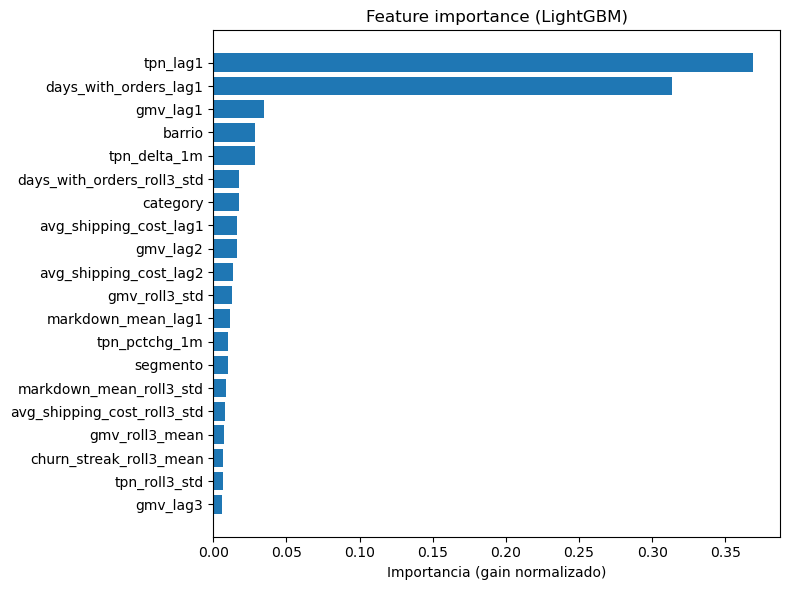

In [189]:
def get_booster(model):
    # Soporta lgb.train (Booster) y LGBMClassifier (wrapper)
    return getattr(model, "booster_", model)

def feature_importance_df(model, feature_names):
    booster = get_booster(model)
    imp_gain  = booster.feature_importance(importance_type='gain')
    imp_split = booster.feature_importance(importance_type='split')
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "gain": imp_gain,
        "split": imp_split
    }).sort_values("gain", ascending=False)
    df_imp["gain_norm"] = df_imp["gain"] / (df_imp["gain"].sum() if df_imp["gain"].sum() > 0 else 1)
    return df_imp

# construir el DF de importancia (usá tu lista 'features')
df_imp = feature_importance_df(run_bin["model"], run_bin["features"])
display(df_imp.head(30))  # top 30 por gain

# gráfico (top 20 por gain normalizado)
top = df_imp.head(20).iloc[::-1]  # invertimos para barh
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["gain_norm"])
plt.xlabel("Importancia (gain normalizado)")
plt.title("Feature importance (LightGBM)")
plt.tight_layout()
plt.show()


In [190]:
# --- 1) Helper: construye df de evaluación con churn_streak (t) desde df_ctx --
def make_eval_df(Xy, mask, y_true, y_score, df_ctx_all, thr, label_month):
    # base con claves + target
    base = Xy.loc[mask, ['store_id','period_month','churn_unique']].copy()
    base = base.rename(columns={'churn_unique':'y'}).reset_index(drop=True)

    # anexar score y pred binaria
    base['score'] = np.asarray(y_score)
    base['yhat']  = (base['score'] >= thr).astype(int)

    # traer churn_streak del MES ACTUAL desde df_ctx
    ctx_cols = ['store_id','period_month','churn_streak']
    ctx = df_ctx_all[ctx_cols].copy()
    ctx['period_month'] = pd.to_datetime(ctx['period_month'])
    base['period_month'] = pd.to_datetime(base['period_month'])

    eval_df = base.merge(ctx, on=['store_id','period_month'], how='left')

    # banderas y clase
    eval_df['streak_flag'] = np.where(pd.to_numeric(eval_df['churn_streak'], errors='coerce').fillna(0) > 0,
                                      'Con streak (>0)', 'Sin streak (=0)')

    def classify(row):
        if row['y']==1 and row['yhat']==1: return 'TP'
        if row['y']==1 and row['yhat']==0: return 'FN'
        if row['y']==0 and row['yhat']==1: return 'FP'
        return 'TN'
    eval_df['clase'] = eval_df.apply(classify, axis=1)

    # (opcional) filtrar por el mes exacto (por seguridad)
    if isinstance(label_month, str):
        pmask = (eval_df['period_month'].dt.to_period('M') == pd.Period(label_month))
        eval_df = eval_df.loc[pmask].copy()

    return eval_df

# --- 2) Construir eval_df para VALID (julio) y TEST (agosto) ---
thr = thr_f2  # o el umbral que elijas

eval_valid = make_eval_df(Xy, valid_mask, y_valid, valid_pred, df_ctx_all, thr, '2025-07')
eval_test  = make_eval_df(Xy, test_mask,  y_test,  test_pred,  df_ctx_all, thr, '2025-08')

# --- 3) Tablas: por clase (TP/FN/FP/TN) × streak_flag ---
def streak_table(eval_df, title):
    cnt = (eval_df
           .groupby(['clase','streak_flag'])
           .size()
           .unstack(fill_value=0)
           .loc[['TP','FN','FP','TN']])  # orden fijo
    pct = (cnt.div(cnt.sum(axis=1), axis=0)*100).round(1)
    print(f"\n{title} — Conteos")
    display(cnt)
    print(f"{title} — Porcentajes dentro de cada clase")
    display(pct)
    return cnt, pct

cnt_valid, pct_valid = streak_table(eval_valid, "VALID (Jul 2025)")
cnt_test,  pct_test  = streak_table(eval_test,  "TEST  (Ago 2025)")



VALID (Jul 2025) — Conteos


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,141,0
FN,42,0
FP,0,293
TN,954,2052


VALID (Jul 2025) — Porcentajes dentro de cada clase


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,100.0,0.0
FN,100.0,0.0
FP,0.0,100.0
TN,31.7,68.3



TEST  (Ago 2025) — Conteos


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,135,0
FN,47,0
FP,0,297
TN,1080,3734


TEST  (Ago 2025) — Porcentajes dentro de cada clase


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,100.0,0.0
FN,100.0,0.0
FP,0.0,100.0
TN,22.4,77.6


In [222]:
# === Distribución de churn_streak por clase (TP/FN/FP/TN) ===
def distrib_streak_por_clase(eval_df, titulo="(t)"):
    clases = ["TP","FN","FP","TN"]
    out = {}
    for cls in clases:
        sub = eval_df.loc[eval_df['clase'] == cls, 'churn_streak']
        # tabla de frecuencia
        tab = (sub.value_counts(dropna=False)
                   .sort_index()
                   .to_frame('casos'))
        tab['pct'] = (tab['casos'] / tab['casos'].sum()).round(3)
        out[cls] = tab
        print(f"\n{cls} – distribución de churn_streak en t {titulo}")
        display(tab)

    # bucketizamos: 0 / 1 / >1
    def bucketize(x):
        x = pd.to_numeric(x, errors='coerce')
        if pd.isna(x): return "NaN"
        if x == 0:     return "0"
        if x == 1:     return "1"
        return ">1"

    dfb = eval_df[['clase','churn_streak']].copy()
    dfb['streak_bucket'] = dfb['churn_streak'].map(bucketize)
    pivot = (dfb
             .groupby(['clase','streak_bucket'])
             .size()
             .unstack(fill_value=0)
             .reindex(index=clases, fill_value=0))
    pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0)*100).round(1)

    print("\nResumen por clase (conteos):")
    display(pivot)
    print("Resumen por clase (porcentajes %):")
    display(pivot_pct)

    return out, pivot, pivot_pct

# Usá eval_test (agosto) o eval_valid (julio)
distros, pivot_cnt, pivot_pct = distrib_streak_por_clase(eval_test, titulo="(agosto)")

# === Recall de ONSET puro (streak==1 en t) ===
tp1 = ((eval_test['clase']=="TP") & (eval_test['churn_streak']==1)).sum()
fn1 = ((eval_test['clase']=="FN") & (eval_test['churn_streak']==1)).sum()
recall_onset_puro = tp1 / (tp1 + fn1) if (tp1+fn1)>0 else float('nan')
print(f"\nRecall ONSET puro (streak==1 en agosto): {recall_onset_puro:.3f}")




TP – distribución de churn_streak en t (agosto)


,casos,pct
churn_streak,,
1.0,135,1.0



FN – distribución de churn_streak en t (agosto)


,casos,pct
churn_streak,,
1.0,47,1.0



FP – distribución de churn_streak en t (agosto)


...


Resumen por clase (conteos):


streak_bucket,0,1,>1,NaN
clase,,,,
TP,0,135,0,0
FN,0,47,0,0
FP,297,0,0,0
TN,2192,0,1080,1542


Resumen por clase (porcentajes %):


streak_bucket,0,1,>1,NaN
clase,,,,
TP,0.0,100.0,0.0,0.0
FN,0.0,100.0,0.0,0.0
FP,100.0,0.0,0.0,0.0
TN,45.5,0.0,22.4,32.0



Recall ONSET puro (streak==1 en agosto): 0.742


AGOSTO — Distribución de churn_unique


,casos,%
churn_unique,,
No churn (0),3569,95.1
Churn (1),182,4.9


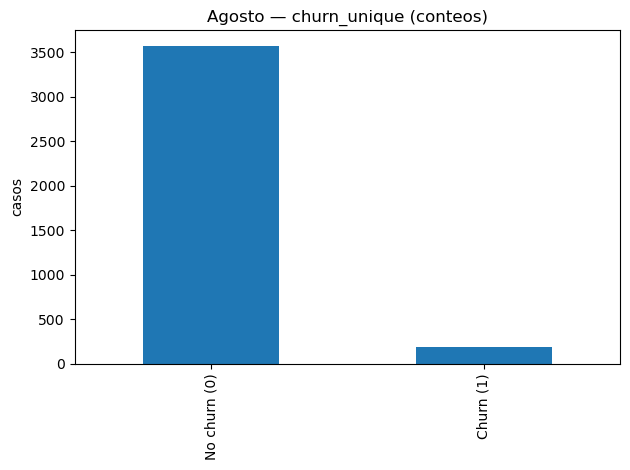

AGOSTO — Distribución de churn_streak (t)


,casos,%
churn_streak,,
0.0,2489,47.0
1.0,182,3.4
2.0,142,2.7
3.0,109,2.1
4.0,122,2.3
5.0,94,1.8
6.0,88,1.7
7.0,75,1.4
8.0,78,1.5


AGOSTO — churn_streak bucketizado (0/1/2/3+/NaN)


,casos,%
streak_bucket,,
0,2489,47.0
1,182,3.4
2,142,2.7
3+,938,17.7
NaN,1542,29.1


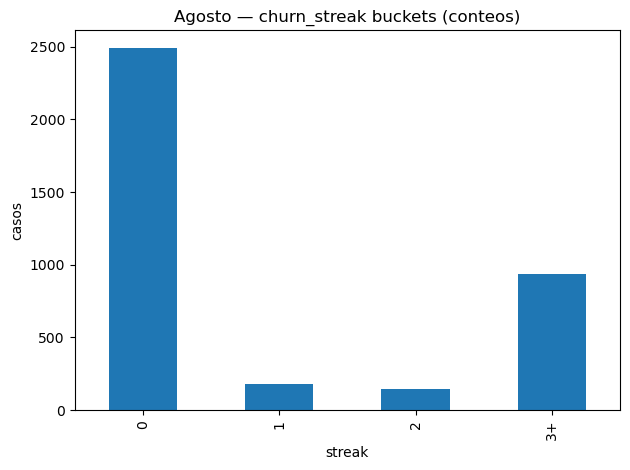

AGOSTO — Cruce churn_unique × streak_bucket (conteos)


streak_bucket,0,1,2,3+,NaN
churn_unique,,,,,
No churn (0),2489,0,142,938,0
Churn (1),0,182,0,0,0


AGOSTO — Cruce churn_unique × streak_bucket (%)


streak_bucket,0,1,2,3+,NaN
churn_unique,,,,,
No churn (0),69.7,0.0,4.0,26.3,0.0
Churn (1),0.0,100.0,0.0,0.0,0.0


In [223]:
# === Distribuciones en AGOSTO 2025 ===
# Usamos la base elegible
aug = df_ctx_all.loc[df_ctx_all['period_month'].dt.to_period('M') == pd.Period('2025-08')].copy()

# Asegurar tipos
aug['churn_unique'] = pd.to_numeric(aug['churn_unique'], errors='coerce')
aug['churn_streak'] = pd.to_numeric(aug['churn_streak'], errors='coerce')

# ----- 1) churn_unique (0/1) -----
cu_cnt = aug.loc[aug['churn_unique'].notna(), 'churn_unique'].value_counts().rename({0:'No churn (0)',1:'Churn (1)'}).to_frame('casos')
cu_pct = (cu_cnt / cu_cnt.sum() * 100).round(1).rename(columns={'casos':'%'})
print("AGOSTO — Distribución de churn_unique")
display(cu_cnt.join(cu_pct))

# (opcional) gráfico
cu_plot = cu_cnt.copy()
cu_plot.plot(kind='bar', legend=False, title='Agosto — churn_unique (conteos)')
plt.ylabel('casos'); plt.xlabel(''); plt.tight_layout(); plt.show()

# ----- 2) churn_streak (conteos y %; ordenado) -----
cs_cnt = aug['churn_streak'].value_counts(dropna=False).sort_index().to_frame('casos')
cs_pct = (cs_cnt / cs_cnt.sum() * 100).round(1).rename(columns={'casos':'%'})
print("AGOSTO — Distribución de churn_streak (t)")
display(cs_cnt.join(cs_pct))

# (opcional) bucketizar 0 / 1 / 2 / 3+
def _bucket_streak(x):
    x = pd.to_numeric(x, errors='coerce')
    if pd.isna(x): return 'NaN'
    if x == 0: return '0'
    if x == 1: return '1'
    if x == 2: return '2'
    return '3+'

aug['streak_bucket'] = aug['churn_streak'].map(_bucket_streak)
sb_cnt = aug['streak_bucket'].value_counts().reindex(['0','1','2','3+','NaN']).fillna(0).astype(int).to_frame('casos')
sb_pct = (sb_cnt / sb_cnt.sum() * 100).round(1).rename(columns={'casos':'%'})
print("AGOSTO — churn_streak bucketizado (0/1/2/3+/NaN)")
display(sb_cnt.join(sb_pct))

# (opcional) gráfico buckets
sb_cnt.loc[['0','1','2','3+']].plot(kind='bar', legend=False, title='Agosto — churn_streak buckets (conteos)')
plt.ylabel('casos'); plt.xlabel('streak'); plt.tight_layout(); plt.show()

# ----- 3) Cruce churn_unique × streak_bucket -----
ct = (aug.loc[aug['churn_unique'].notna()]
        .pivot_table(index='churn_unique', columns='streak_bucket', values='store_id', aggfunc='count', fill_value=0)
        .rename(index={0:'No churn (0)',1:'Churn (1)'})
        .reindex(columns=['0','1','2','3+','NaN'], fill_value=0))
ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)

print("AGOSTO — Cruce churn_unique × streak_bucket (conteos)")
display(ct)
print("AGOSTO — Cruce churn_unique × streak_bucket (%)")
display(ct_pct)


### Prueba con data real de septiembre

In [201]:
data_sep_real = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data_real_septiembre_full.csv')

In [218]:
df_sep = data_sep_real.copy()

# Tipos y columnas
df_sep['created_date'] = pd.to_datetime(df_sep['created_date'], errors='coerce')
df_sep = df_sep.rename(columns={'store_id_anon':'store_id'})

# Target “real” de septiembre: churn_unique = 1 si TPN == 0; 0 si TPN > 0
df_sep['churn_real_any'] = (pd.to_numeric(df_sep['TPN'], errors='coerce').fillna(0) == 0).astype(int)
# nota: 'churn_unique_real' la vamos a construir después usando TPN de agosto

# Alinear tipo de store_id con Xy (por si uno es float)
try:
    df_sep['store_id'] = df_sep['store_id'].astype(int)
except Exception:
    pass
sep_ids = set(df_sep['store_id'].dropna().astype(int))

In [219]:
# Fechas (meses completos)
train_mask = Xy['period_month'].between('2025-04-01','2025-07-31') & Xy['churn_unique'].notna()
valid_mask = Xy['period_month'].between('2025-08-01','2025-08-31') & Xy['churn_unique'].notna()
pred_mask  = (Xy['period_month'].between('2025-08-01','2025-08-31')) & (Xy['store_id'].isin(sep_ids))

run_sep = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, pred_mask,   # test_mask = septiembre
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,        # o tu lista de features si querés restringir
    output_mode="binary",        # ← devuelve proba + binario
    threshold_strategy="f2",     # ← umbral elegido por F2 en AGO (valid)
    beta=2.0
)

# Tomamos lo que vamos a usar
thr_sep     = run_sep["threshold"]      # umbral F2 elegido en AGO
y_valid_aug = run_sep["y_valid"]        # target de AGO (para control)
prob_aug    = run_sep["valid_prob"]     # proba en AGO (para control)
prob_sep    = run_sep["test_prob"]      # proba en SEP (lo que nos interesa)
yhat_sep    = run_sep["test_pred_bin"]  # binario en SEP con thr_sep


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.988053	train's average_precision: 0.766894	valid's auc: 0.931353	valid's average_precision: 0.393237
[200]	train's auc: 0.9986	train's average_precision: 0.961287	valid's auc: 0.929628	valid's average_precision: 0.379104
Early stopping, best iteration is:
[25]	train's auc: 0.955366	train's average_precision: 0.426966	valid's auc: 0.933168	valid's average_precision: 0.362171


# Evaluar performance (hasta acá funciona ok la parte de sep. de acá en adelante rompe)

In [ ]:
# Extraer claves del set de septiembre desde Xy
keys_sep = Xy.loc[pred_mask, ['store_id']].reset_index(drop=True)

# TPN de AGOSTO desde tu base modelada (para detectar ONSET en septiembre)
aug = df_ctx_all[df_ctx_all['period_month'].dt.to_period('M') == pd.Period('2025-08')][['store_id','tpn']].copy()
aug = aug.rename(columns={'tpn':'TPN_aug'})


pred_sep_df = keys_sep.assign(
    score = prob_sep,
    yhat  = yhat_sep
)

# Marcar mes de predicción = septiembre 2025
pred_sep_df['period_month'] = pd.Timestamp('2025-09-01')

pred_sep_df = pred_sep_df.drop_duplicates(subset='store_id')
df_sep_u = df_sep.drop_duplicates(subset='store_id', keep='last')[['store_id','churn_real_any']]

# Usar df_sep_u deduplicado por store_id (ya lo habías agregado)
# OJO: ahora 'churn_real_any' viene de df_sep
eval_sep = (pred_sep_df
            .merge(df_sep_u.rename(columns={'churn_unique_real':'churn_real_any'}), on='store_id', how='left')
            .merge(aug, on='store_id', how='left'))

# ONSET real de septiembre: sin ventas en sep (churn_real_any==1) Y sí había ventas en agosto
eval_sep['churn_unique_real'] = (
    (eval_sep['churn_real_any'] == 1) &
    (pd.to_numeric(eval_sep['TPN_aug'], errors='coerce').fillna(0) > 0)
).astype(int)


# Chequeo de cobertura
n_pred  = len(pred_sep_df)
n_match = eval_sep['churn_unique_real'].notna().sum()
print(f"Predicciones SEP: {n_pred} | Matcheadas contra data_sep_real: {n_match}")


KeyError: "['churn_unique_real'] not in index"

In [212]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score
)
import numpy as np

# Filas con target real disponible
m = eval_sep['churn_unique_real'].notna()
y_true_sep = eval_sep.loc[m, 'churn_unique_real'].astype(int).values
p_sep      = eval_sep.loc[m, 'score'].values
yhat_bin   = eval_sep.loc[m, 'yhat'].astype(int).values

cm = confusion_matrix(y_true_sep, yhat_bin, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

metrics_sep = {
    "threshold": float(thr_sep),
    "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    "precision": precision_score(y_true_sep, yhat_bin, zero_division=0),
    "recall":    recall_score(y_true_sep, yhat_bin, zero_division=0),
    "f1":        f1_score(y_true_sep, yhat_bin, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_true_sep, yhat_bin),
    "AUC":   roc_auc_score(y_true_sep, p_sep),
    "AUPRC": average_precision_score(y_true_sep, p_sep),
    "base_rate": float(np.mean(y_true_sep))
}
print("— SEP 2025 —")
for k,v in metrics_sep.items():
    print(f"{k:>18}: {v}")


— SEP 2025 —
         threshold: 0.46793699497572594
                TP: 0
                FP: 195
                TN: 1910
                FN: 0
         precision: 0.0
            recall: 0.0
                f1: 0.0
 balanced_accuracy: 0.9073634204275535
               AUC: nan
             AUPRC: 0.0
         base_rate: 0.0


/Users/danna/miniconda3/envs/eda_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/danna/miniconda3/envs/eda_env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/danna/miniconda3/envs/eda_env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


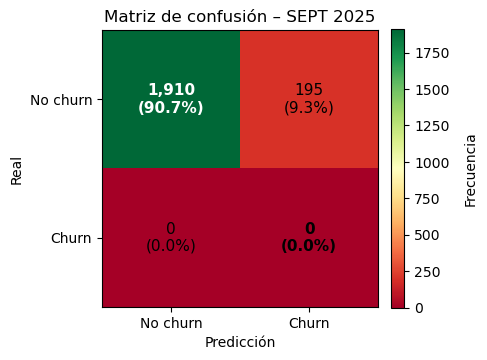

In [213]:
plot_confusion(cm, title="Matriz de confusión – SEPT 2025", percent=True)

In [214]:
(df_sep['TPN'].fillna(0).astype(float) == 0).sum()

np.int64(10055)

In [215]:
(df_sep['TPN'].fillna(0).astype(float) != 0).sum()


np.int64(96067)

# LightGBM probabilístico

In [167]:
# ENTRENAR → devuelve PROBABILIDADES (no binariza)
run_proba = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,     # o tu lista específica de features
    output_mode="proba"       # <<--- clave: modo probabilístico
)

# Tomo targets y probabilidades
y_valid    = run_proba["y_valid"]
y_test     = run_proba["y_test"]
valid_prob = run_proba["valid_prob"]
test_prob  = run_proba["test_prob"]


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.991788	train's average_precision: 0.817587	valid's auc: 0.923075	valid's average_precision: 0.3963
[200]	train's auc: 0.999417	train's average_precision: 0.982662	valid's auc: 0.919972	valid's average_precision: 0.392673
Early stopping, best iteration is:
[48]	train's auc: 0.970733	train's average_precision: 0.553517	valid's auc: 0.924678	valid's average_precision: 0.400752


In [168]:
thr_f2, p_f2, r_f2, f2 = pick_threshold_by_fbeta(y_valid, valid_prob, beta=2.0)
print(f"Umbral F2 (VALID): {thr_f2:.4f} | P={p_f2:.3f} R={r_f2:.3f} F2={f2:.3f}")

Umbral F2 (VALID): 0.5421 | P=0.326 R=0.760 F2=0.600


In [169]:
def prob_dist_plot(y_true, y_prob, thr=None, title="Distribución de probabilidades"):
    y = pd.Series(y_true).reset_index(drop=True).astype(int)
    p = np.asarray(y_prob)
    bins = np.linspace(0, 1, 26)

    plt.figure(figsize=(7,4))
    plt.hist(p[y==0], bins=bins, alpha=0.7, label="Clase 0 (no onset)")
    plt.hist(p[y==1], bins=bins, alpha=0.7, label="Clase 1 (onset)")
    if thr is not None:
        plt.axvline(thr, linestyle="--")
    ap  = average_precision_score(y, p)
    auc = roc_auc_score(y, p)
    plt.title(f"{title}  |  AP={ap:.3f}  AUC={auc:.3f}")
    plt.xlabel("Probabilidad predicha")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

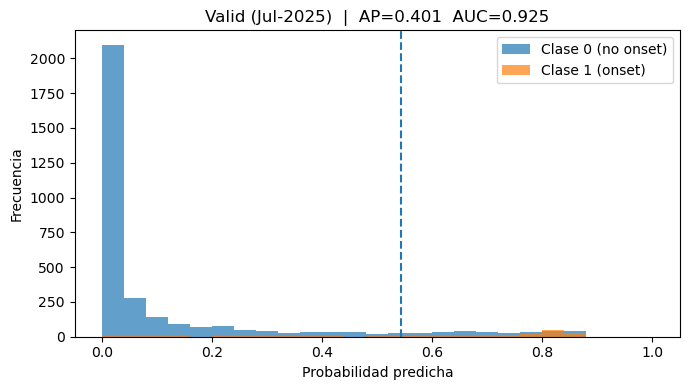

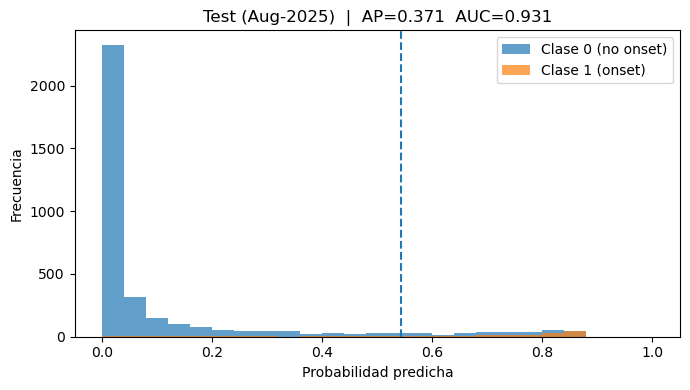

In [170]:
# Con línea en el umbral F2 (opcional). Si no querés línea: pasá thr=None.
prob_dist_plot(y_valid, valid_prob, thr=thr_f2, title="Valid (Jul-2025)")
prob_dist_plot(y_test,  test_prob,  thr=thr_f2, title="Test (Aug-2025)")